In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler

In [70]:
df = pd.read_csv(
    "../data/raw/Student_performance_data _ (1).csv"
)

In [71]:

df["SupportScore"] = (
    df["Tutoring"] +
    df["ParentalSupport"]
)

df["ActivityScore"] = (
    df["Extracurricular"] +
    df["Sports"] +
    df["Music"] +
    df["Volunteering"]
)

df["AbsenceRatio"] = (
    df["Absences"] /
    df["Absences"].max()
)

In [72]:
X = df.drop(
    ["GPA", "StudentID", "GradeClass"],
    axis=1
)

y = df["GPA"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [75]:
lr_model = LinearRegression()
lr_model.fit(
    X_train,
    y_train
)
y_pred_lr = lr_model.predict(
    X_test
)

In [76]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(
    X_train_scaled,
    y_train
)
y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

In [77]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(
    X_train_scaled,
    y_train
)
y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

In [78]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)
y_pred_rf = rf_model.predict(
    X_test
)

In [79]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_model.fit(
    X_train,
    y_train
)
y_pred_gb = gb_model.predict(
    X_test
)

In [80]:
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)
xgb_model.fit(
    X_train,
    y_train
)
y_pred_xgb = xgb_model.predict(
    X_test
)

In [81]:
print(y_pred_lr[:5])
print(y_pred_rf[:5])
print(y_pred_xgb[:5])

[1.47962878 2.91427518 1.77206275 3.52163738 0.25163087]
[1.40801615 3.10202899 1.97469258 3.39382856 0.3520155 ]
[1.6297741 3.0456042 1.8659949 3.4843874 0.5922358]


In [82]:
print("Linear Regression trained.")
print("Ridge Regression trained.")
print("Lasso Regression trained.")
print("Random Forest trained.")
print("Gradient Boosting trained.")
print("XGBoost trained.")

Linear Regression trained.
Ridge Regression trained.
Lasso Regression trained.
Random Forest trained.
Gradient Boosting trained.
XGBoost trained.


In [83]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

In [84]:
models = {
    "Linear Regression": (
        lr_model,
        y_pred_lr,
        X_train,
        X_test
    ),

    "Ridge Regression": (
        ridge_model,
        y_pred_ridge,
        X_train_scaled,
        X_test_scaled
    ),

    "Lasso Regression": (
        lasso_model,
        y_pred_lasso,
        X_train_scaled,
        X_test_scaled
    ),

    "Random Forest": (
        rf_model,
        y_pred_rf,
        X_train,
        X_test
    ),

    "Gradient Boosting": (
        gb_model,
        y_pred_gb,
        X_train,
        X_test
    ),

    "XGBoost": (
        xgb_model,
        y_pred_xgb,
        X_train,
        X_test
    )
}

In [85]:
results = []

In [86]:
for name, (
    model,
    pred,
    Xtr,
    Xte
) in models.items():

    mae = mean_absolute_error(
        y_test,
        pred
    )

    mse = mean_squared_error(
        y_test,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        pred
    )

    train_r2 = r2_score(
        y_train,
        model.predict(Xtr)
    )

    cv_r2 = cross_val_score(
        model,
        Xtr,
        y_train,
        cv=5,
        scoring='r2'
    ).mean()

    overfit_gap = (
        train_r2 - r2
    )

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        cv_r2,
        train_r2,
        overfit_gap
    ])

In [87]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "CV R2 Score",
        "Train R2",
        "Overfit Gap"
    ]
)

In [88]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

In [89]:
results_df

,Model,MAE,MSE,RMSE,R2 Score,CV R2 Score,Train R2,Overfit Gap
0,Linear Regression,0.155295,0.038661,0.196625,0.953247,0.953086,0.954148,0.000901
1,Ridge Regression,0.155308,0.038667,0.196639,0.953241,0.953087,0.954148,0.000907
2,Lasso Regression,0.156815,0.039717,0.199292,0.951970,0.952364,0.953234,0.001264
4,Gradient Boosting,0.163841,0.043920,0.209570,0.946889,0.946615,0.962385,0.015496
5,XGBoost,0.181774,0.050655,0.225066,0.938744,0.934208,0.996938,0.058195
3,Random Forest,0.184095,0.055256,0.235066,0.933180,0.934045,0.991183,0.058003


In [90]:
for name, (
    model,
    pred,
    Xtr,
    Xte
) in models.items():

    mae = mean_absolute_error(
        y_test,
        pred
    )

    mse = mean_squared_error(
        y_test,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        pred
    )

    cv_r2 = cross_val_score(
        model,
        Xtr,
        y_train,
        cv=5,
        scoring='r2'
    ).mean()

    print("----------------------------------")

    print(f"Model : {name}")

    print("MAE   :", round(mae,4))

    print("MSE   :", round(mse,4))

    print("RMSE  :", round(rmse,4))

    print("R²    :", round(r2,4))

    print(
        "CV R² (5-fold):",
        round(cv_r2,4)
    )

    print("----------------------------------\n")

----------------------------------
Model : Linear Regression
MAE   : 0.1553
MSE   : 0.0387
RMSE  : 0.1966
R²    : 0.9532
CV R² (5-fold): 0.9531
----------------------------------

----------------------------------
Model : Ridge Regression
MAE   : 0.1553
MSE   : 0.0387
RMSE  : 0.1966
R²    : 0.9532
CV R² (5-fold): 0.9531
----------------------------------

----------------------------------
Model : Lasso Regression
MAE   : 0.1568
MSE   : 0.0397
RMSE  : 0.1993
R²    : 0.952
CV R² (5-fold): 0.9524
----------------------------------

----------------------------------
Model : Random Forest
MAE   : 0.1841
MSE   : 0.0553
RMSE  : 0.2351
R²    : 0.9332
CV R² (5-fold): 0.934
----------------------------------

----------------------------------
Model : Gradient Boosting
MAE   : 0.1638
MSE   : 0.0439
RMSE  : 0.2096
R²    : 0.9469
CV R² (5-fold): 0.9466
----------------------------------

----------------------------------
Model : XGBoost
MAE   : 0.1818
MSE   : 0.0507
RMSE  : 0.2251
R²    : 0.93

In [91]:
print("="*50)

print("OVERFITTING CHECK (Train vs Test R²)")

print("="*50)

for name, (
    model,
    pred,
    Xtr,
    Xte
) in models.items():

    train_r2 = r2_score(
        y_train,
        model.predict(Xtr)
    )

    test_r2 = r2_score(
        y_test,
        pred
    )

    difference = abs(
        train_r2 - test_r2
    )

    status = (
        "OK"
        if difference < 0.10
        else "OVERFITTING"
    )

    print(
        f"{name:<20} "
        f"Train R²={train_r2:.3f}  "
        f"Test R²={test_r2:.3f}  "
        f"Difference={difference:.3f}  "
        f"{status}"
    )

OVERFITTING CHECK (Train vs Test R²)
Linear Regression    Train R²=0.954  Test R²=0.953  Difference=0.001  OK
Ridge Regression     Train R²=0.954  Test R²=0.953  Difference=0.001  OK
Lasso Regression     Train R²=0.953  Test R²=0.952  Difference=0.001  OK
Random Forest        Train R²=0.991  Test R²=0.933  Difference=0.058  OK
Gradient Boosting    Train R²=0.962  Test R²=0.947  Difference=0.015  OK
XGBoost              Train R²=0.997  Test R²=0.939  Difference=0.058  OK


In [92]:
param_grid = {

    'n_estimators': [
        100,
        200
    ],

    'max_depth': [
        None,
        5,
        10
    ],

    'min_samples_split': [
        2,
        5
    ],

    'max_features': [
        'sqrt',
        0.5
    ]
}

In [93]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1
)

In [94]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 0.5], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [95]:
print(
    grid_search.best_params_
)

{'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 200}


In [96]:
best_rf = grid_search.best_estimator_

In [97]:
y_pred_best = best_rf.predict(
    X_test
)

In [98]:
mae = mean_absolute_error(
    y_test,
    y_pred_best
)

mse = mean_squared_error(
    y_test,
    y_pred_best
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred_best
)

cv_r2 = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
).mean()

In [99]:
print("="*50)

print("TUNED RANDOM FOREST RESULTS")

print("="*50)

print("MAE   :", round(mae,4))

print("MSE   :", round(mse,4))

print("RMSE  :", round(rmse,4))

print("R²    :", round(r2,4))

print(
    "CV R² (5-fold):",
    round(cv_r2,4)
)

print("="*50)

TUNED RANDOM FOREST RESULTS
MAE   : 0.1792
MSE   : 0.0527
RMSE  : 0.2296
R²    : 0.9363
CV R² (5-fold): 0.9379


In [100]:
importance_df = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)


,Feature,Importance
14,AbsenceRatio,0.432550
5,Absences,0.417761
4,StudyTimeWeekly,0.051070
12,SupportScore,0.033553
13,ActivityScore,0.012599
7,ParentalSupport,0.011705
6,Tutoring,0.007601
0,Age,0.005803
3,ParentalEducation,0.005740
2,Ethnicity,0.004966


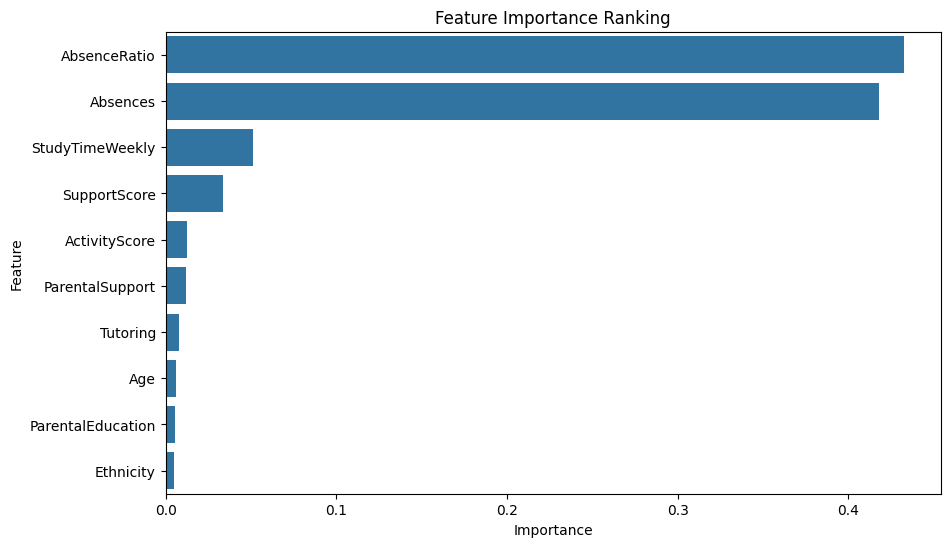

In [101]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title(
    "Feature Importance Ranking"
)

plt.show()

In [102]:
print(X.columns.tolist())

['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'SupportScore', 'ActivityScore', 'AbsenceRatio']
